In [4]:
from pathlib import Path

PROJECT_ROOT = Path(r"A:\Coding\PycharmProjects\cryptoguard")
MODELS_ROOT  = PROJECT_ROOT / "models"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"
RESULTS_DIR  = PROJECT_ROOT / "outputs" / "results"
DATA_ROOT    = PROJECT_ROOT / "data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GENERAL_TEST_PATH    = DATA_ROOT / "general"    / "test.csv"
BLOCKCHAIN_TEST_PATH = DATA_ROOT / "blockchain" / "blockchain_test.csv"

MODEL_REGISTRY = [
    ("TF-IDF General",         "tfidf_general",         "tfidf"),
    ("TF-IDF Blockchain",      "tfidf_blockchain",      "tfidf"),
    ("DistilBERT General",     "distilbert_general",    "transformer"),
    ("BERT General",           "bert_general",          "transformer"),
    ("RoBERTa General",        "roberta_general",       "transformer"),
    ("DistilBERT Blockchain",  "distilbert_blockchain", "transformer"),
    ("BERT Blockchain",        "bert_blockchain",       "transformer"),
    ("RoBERTa Blockchain",     "roberta_blockchain",    "transformer"),
]

MAX_LEN    = 256
BATCH_SIZE = 32

print(f"Models root     : {MODELS_ROOT}")
print(f"Figures dir     : {FIGURES_DIR}")
print(f"Results dir     : {RESULTS_DIR}")
print(f"General test    : {GENERAL_TEST_PATH}")
print(f"Blockchain test : {BLOCKCHAIN_TEST_PATH}")

print("\nCheckpoint verification:")
for display_name, folder, _ in MODEL_REGISTRY:
    path   = MODELS_ROOT / folder
    print(f" {display_name:25s} {path}")

Models root     : A:\Coding\PycharmProjects\cryptoguard\models
Figures dir     : A:\Coding\PycharmProjects\cryptoguard\outputs\figures
Results dir     : A:\Coding\PycharmProjects\cryptoguard\outputs\results
General test    : A:\Coding\PycharmProjects\cryptoguard\data\general\test.csv
Blockchain test : A:\Coding\PycharmProjects\cryptoguard\data\blockchain\blockchain_test.csv

Checkpoint verification:
  ✓  TF-IDF General            → A:\Coding\PycharmProjects\cryptoguard\models\tfidf_general
  ✓  TF-IDF Blockchain         → A:\Coding\PycharmProjects\cryptoguard\models\tfidf_blockchain
  ✓  DistilBERT General        → A:\Coding\PycharmProjects\cryptoguard\models\distilbert_general
  ✓  BERT General              → A:\Coding\PycharmProjects\cryptoguard\models\bert_general
  ✓  RoBERTa General           → A:\Coding\PycharmProjects\cryptoguard\models\roberta_general
  ✓  DistilBERT Blockchain     → A:\Coding\PycharmProjects\cryptoguard\models\distilbert_blockchain
  ✓  BERT Blockchain        

In [5]:
import numpy as np
import pandas as pd
import pickle
import json
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [6]:
df_general    = pd.read_csv(GENERAL_TEST_PATH)
df_blockchain = pd.read_csv(BLOCKCHAIN_TEST_PATH)

for df in [df_general, df_blockchain]:
    df['label'] = df['label'].astype(int)

print(f"General test    : {len(df_general):,} samples | "
      f"label dist: {df_general['label'].value_counts().sort_index().to_dict()}")
print(f"Blockchain test : {len(df_blockchain):,} samples | "
      f"label dist: {df_blockchain['label'].value_counts().sort_index().to_dict()}")

TEST_SETS = {
    "general":    (df_general,    df_general['label'].values),
    "blockchain": (df_blockchain, df_blockchain['label'].values),
}

General test    : 1,600 samples | label dist: {0: 800, 1: 800}
Blockchain test : 796 samples | label dist: {0: 398, 1: 398}


In [7]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokeniser = tokeniser
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokeniser(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy":  round(accuracy_score(y_true,  y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true,    y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_true,        y_pred, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_true,   y_prob), 4),
    }


def predict_transformer(checkpoint_path, df, max_len, batch_size, device):
    tokeniser = AutoTokenizer.from_pretrained(checkpoint_path)
    model     = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)
    model.to(device)
    model.eval()

    ds     = TextDataset(df['text'].tolist(), df['label'].tolist(), tokeniser, max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device),
            )
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)

    del model
    torch.cuda.empty_cache()
    return np.array(all_preds), np.array(all_probs)


def predict_tfidf(checkpoint_path, df):
    with open(checkpoint_path / "vectorizer.pkl",  "rb") as f:
        vectorizer = pickle.load(f)
    with open(checkpoint_path / "classifier.pkl",  "rb") as f:
        clf = pickle.load(f)
    X     = vectorizer.transform(df['text'])
    preds = clf.predict(X)
    probs = clf.predict_proba(X)[:, 1]
    return np.array(preds), np.array(probs)

Helpers loaded.


In [11]:
all_results     = []
all_roc_data    = {}
all_preds_store = {}

for display_name, folder, model_type in MODEL_REGISTRY:
    checkpoint_path = MODELS_ROOT / folder
    print(f"Model: {display_name}")

    all_roc_data[display_name]    = {}
    all_preds_store[display_name] = {}

    for test_name, (df_test, y_true) in TEST_SETS.items():

        if model_type == "tfidf":
            y_pred, y_prob = predict_tfidf(checkpoint_path, df_test)
        else:
            y_pred, y_prob = predict_transformer(
                str(checkpoint_path), df_test, MAX_LEN, BATCH_SIZE, device
            )

        metrics = compute_metrics(y_true, y_pred, y_prob)

        print(f"  [{test_name:10s}]  "
              f"Acc={metrics['accuracy']:.4f}  "
              f"P={metrics['precision']:.4f}  "
              f"R={metrics['recall']:.4f}  "
              f"F1={metrics['f1']:.4f}  "
              f"AUC={metrics['roc_auc']:.4f}")

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        all_roc_data[display_name][test_name]    = (fpr, tpr, metrics['roc_auc'])
        all_preds_store[display_name][test_name] = (y_true, y_pred, y_prob)

        all_results.append({
            "model":    display_name,
            "test_set": test_name,
            **metrics,
        })

        #save predictions for McNemar tests
        pred_dir = RESULTS_DIR / folder
        pred_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame({
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob":  y_prob,
        }).to_csv(pred_dir / f"predictions_{test_name}.csv", index=False)

print(f"\nEvaluation complete")


Model: TF-IDF General


A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from ver

  [general   ]  Acc=0.9788  P=0.9705  R=0.9875  F1=0.9789  AUC=0.9980
  [blockchain]  Acc=0.5126  P=0.5065  R=0.9824  F1=0.6684  AUC=0.6010

Model: TF-IDF Blockchain


A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from ver

  [general   ]  Acc=0.4969  P=0.4981  R=0.8287  F1=0.6222  AUC=0.5471
  [blockchain]  Acc=0.9749  P=0.9565  R=0.9950  F1=0.9754  AUC=0.9975

Model: DistilBERT General


...

  [blockchain]  Acc=0.9899  P=0.9899  R=0.9899  F1=0.9899  AUC=0.9996

Model: RoBERTa Blockchain


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6751.95it/s]


  [general   ]  Acc=0.9775  P=0.9872  R=0.9675  F1=0.9773  AUC=0.9968


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6474.48it/s]


  [blockchain]  Acc=0.9962  P=0.9950  R=0.9975  F1=0.9962  AUC=0.9999

✓  Evaluation complete — 16 result rows


In [12]:
df_results = pd.DataFrame(all_results)

df_pivot = df_results.pivot_table(
    index="model",
    columns="test_set",
    values=["accuracy", "precision", "recall", "f1", "roc_auc"],
    aggfunc="first",
)

model_order = [m[0] for m in MODEL_REGISTRY]
df_pivot    = df_pivot.reindex(model_order)

print("Master Results Table (all 40 metrics):")
print(df_pivot.to_string())

df_results.to_csv(RESULTS_DIR / "all_results.csv",   index=False)
df_pivot.to_csv(RESULTS_DIR   / "results_pivot.csv")

Master Results Table (all 40 metrics):
                        accuracy                 f1          precision             recall            roc_auc        
test_set              blockchain general blockchain general blockchain general blockchain general blockchain general
model                                                                                                               
TF-IDF General            0.5126  0.9788     0.6684  0.9789     0.5065  0.9705     0.9824  0.9875     0.6010  0.9980
TF-IDF Blockchain         0.9749  0.4969     0.9754  0.6222     0.9565  0.4981     0.9950  0.8287     0.9975  0.5471
DistilBERT General        0.4774  0.9875     0.5832  0.9875     0.4850  0.9851     0.7312  0.9900     0.5237  0.9967
BERT General              0.4849  0.9906     0.6019  0.9907     0.4905  0.9876     0.7789  0.9938     0.5535  0.9982
RoBERTa General           0.5415  0.9906     0.6302  0.9906     0.5280  0.9888     0.7814  0.9925     0.6001  0.9984
DistilBERT Blockchain    

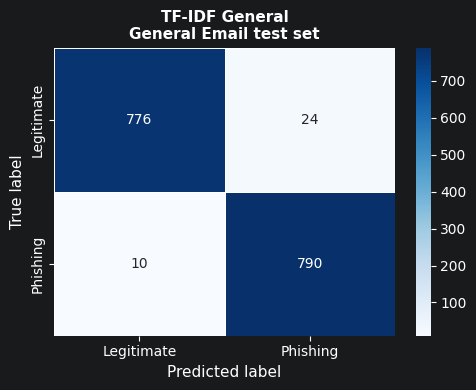

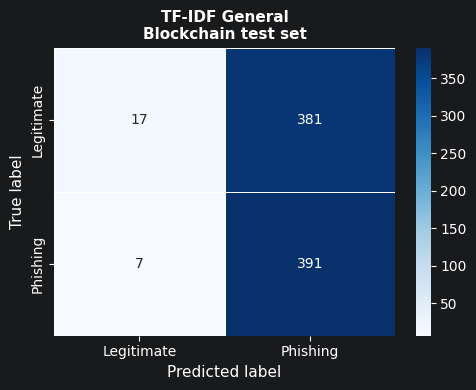

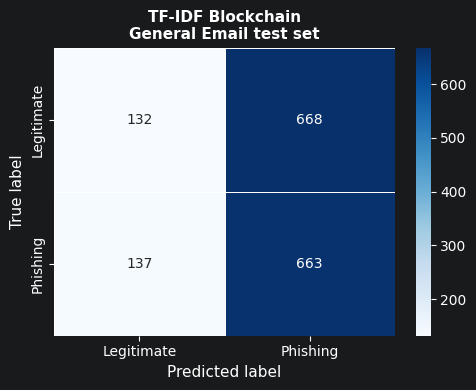

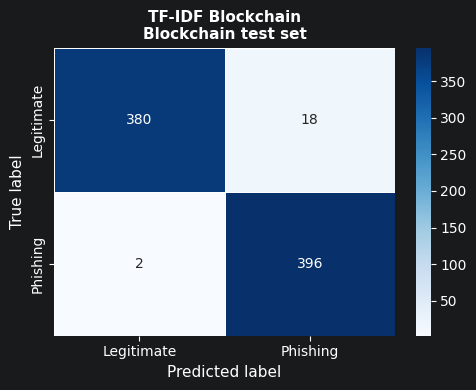

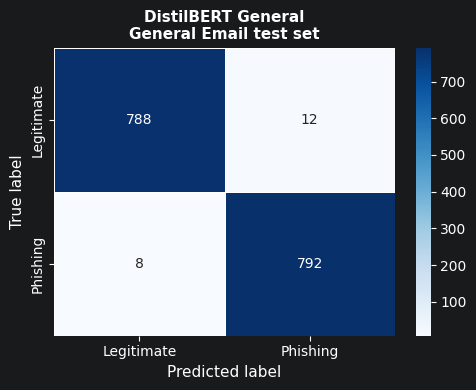

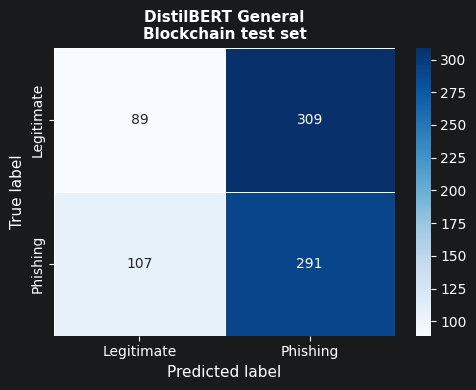

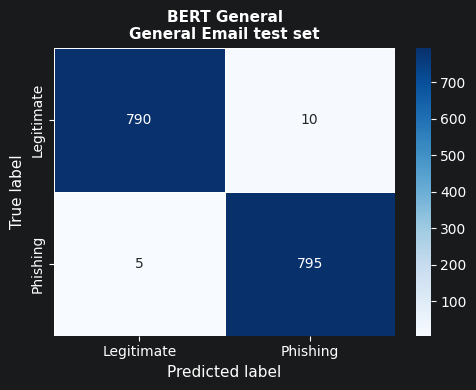

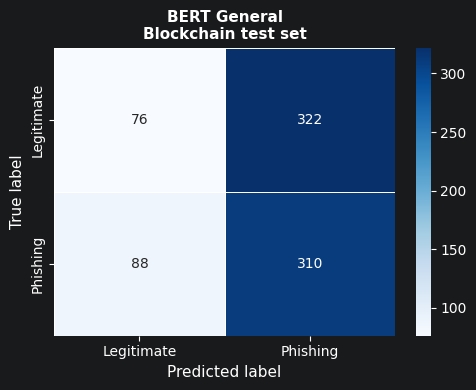

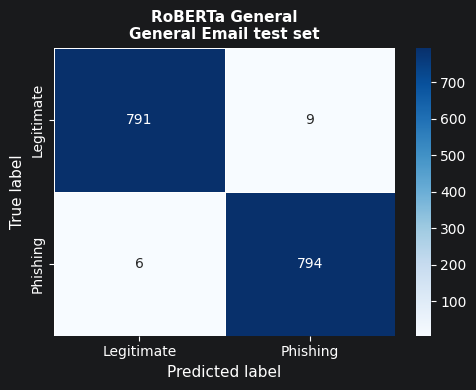

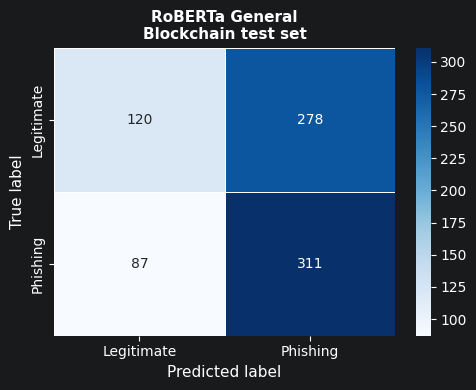

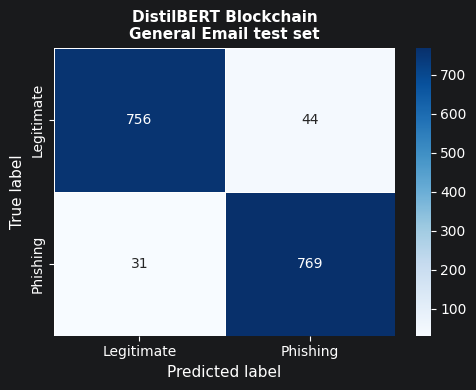

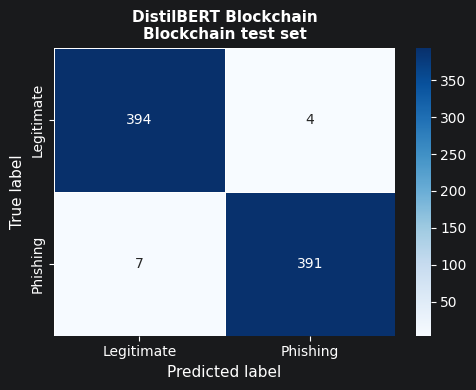

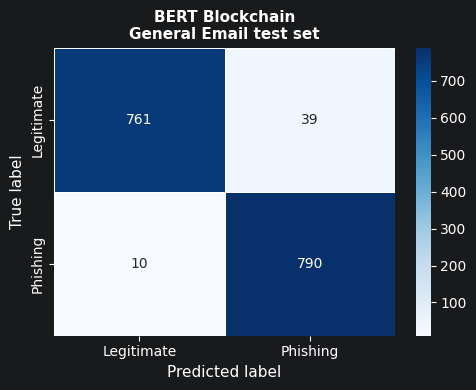

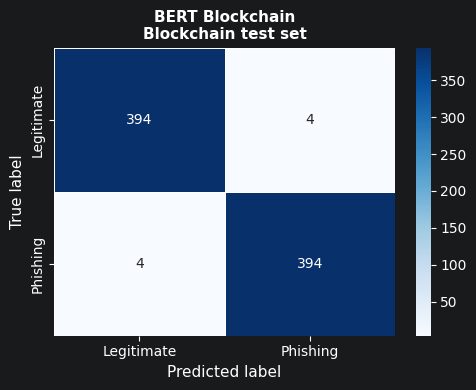

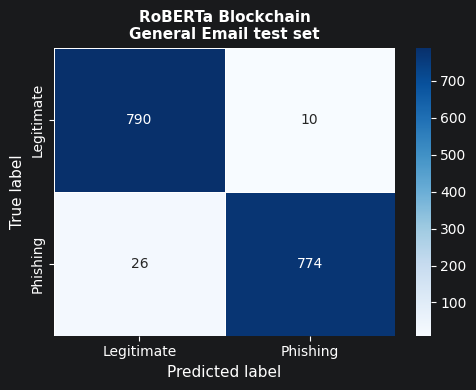

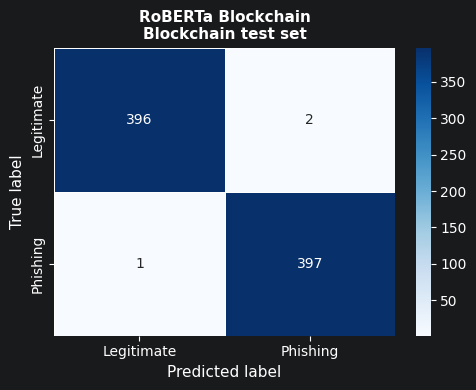

✓  16 confusion matrices saved to A:\Coding\PycharmProjects\cryptoguard\outputs\figures


In [13]:
for display_name, _, _ in MODEL_REGISTRY:
    for test_name in ["general", "blockchain"]:
        y_true, y_pred, _ = all_preds_store[display_name][test_name]
        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            ax=ax,
            linewidths=0.5,
            linecolor='white',
        )
        ax.set_xlabel('Predicted label', fontsize=11)
        ax.set_ylabel('True label', fontsize=11)
        corpus_label = "General Email" if test_name == "general" else "Blockchain"
        ax.set_title(f"{display_name}\n{corpus_label} test set",
                     fontsize=11, fontweight='bold')

        plt.tight_layout()
        safe_name = display_name.lower().replace(' ', '_')
        path = FIGURES_DIR / f"confusion_matrix_{safe_name}_{test_name}.png"
        plt.savefig(str(path), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

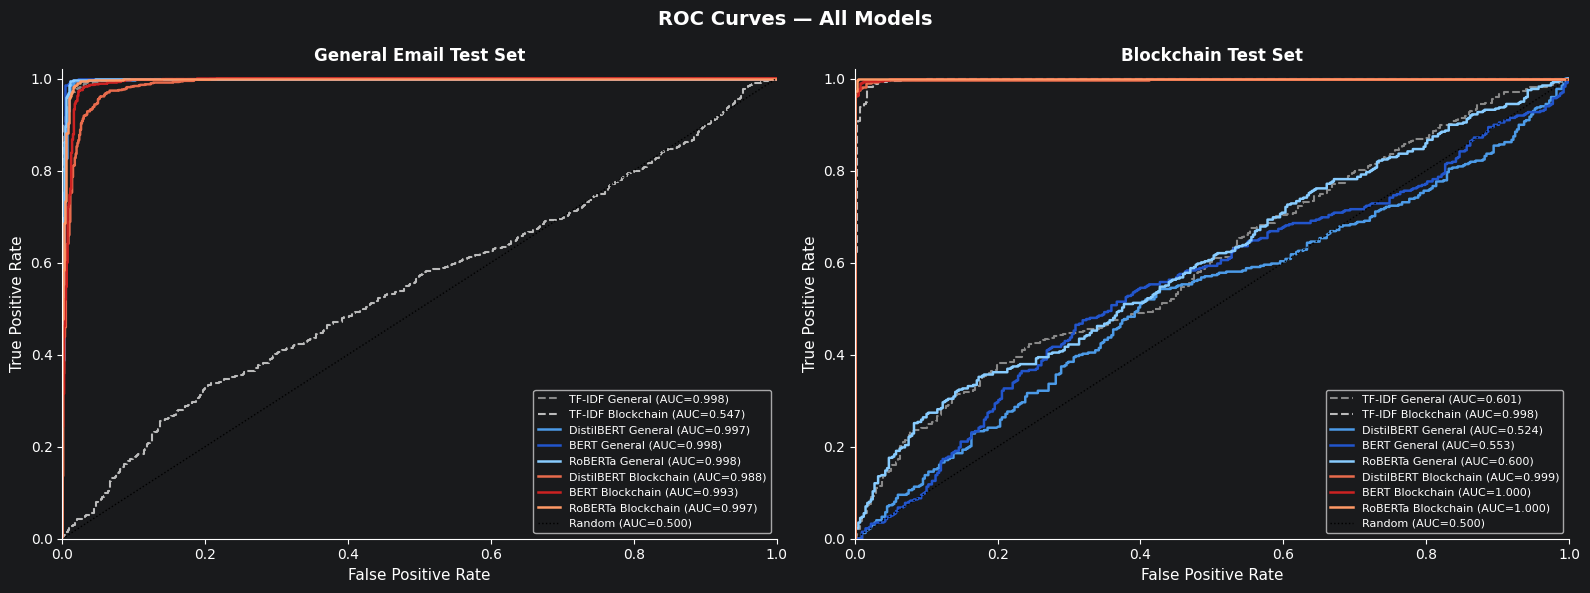

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\figures\roc_overlay_all_models.png


In [14]:
PLOT_STYLE = {
    "TF-IDF General":        {"color": "#888888", "ls": "--", "lw": 1.5},
    "TF-IDF Blockchain":     {"color": "#BBBBBB", "ls": "--", "lw": 1.5},
    "DistilBERT General":    {"color": "#4C9BE8", "ls": "-",  "lw": 1.8},
    "BERT General":          {"color": "#2255CC", "ls": "-",  "lw": 1.8},
    "RoBERTa General":       {"color": "#88CCFF", "ls": "-",  "lw": 1.8},
    "DistilBERT Blockchain": {"color": "#E86B4C", "ls": "-",  "lw": 1.8},
    "BERT Blockchain":       {"color": "#CC2222", "ls": "-",  "lw": 1.8},
    "RoBERTa Blockchain":    {"color": "#FF9966", "ls": "-",  "lw": 1.8},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ROC Curves — All Models", fontsize=14, fontweight='bold')

for ax, test_name, panel_title in zip(
    axes,
    ["general", "blockchain"],
    ["General Email Test Set", "Blockchain Test Set"],
):
    for display_name, _, _ in MODEL_REGISTRY:
        fpr, tpr, auc = all_roc_data[display_name][test_name]
        style = PLOT_STYLE[display_name]
        ax.plot(
            fpr, tpr,
            color=style["color"],
            linestyle=style["ls"],
            linewidth=style["lw"],
            label=f"{display_name} (AUC={auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random (AUC=0.500)')
    ax.set_title(panel_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

plt.tight_layout()
roc_path = FIGURES_DIR / "roc_overlay_all_models.png"
plt.savefig(str(roc_path), dpi=150, bbox_inches='tight')
plt.show()

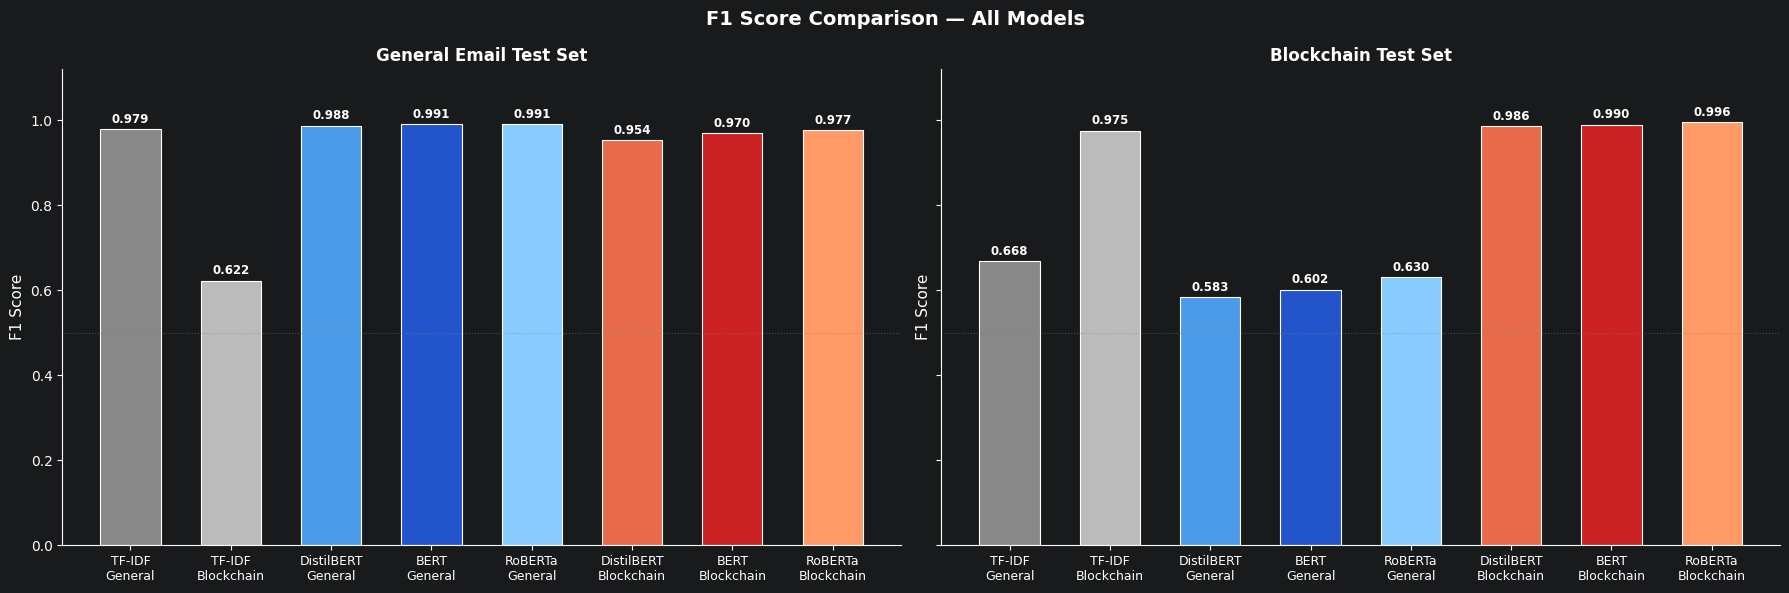

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\figures\f1_comparison_all_models.png


In [15]:
model_names = [m[0] for m in MODEL_REGISTRY]

f1_general = [
    df_results[(df_results['model'] == m) &
               (df_results['test_set'] == 'general')]['f1'].values[0]
    for m in model_names
]
f1_blockchain = [
    df_results[(df_results['model'] == m) &
               (df_results['test_set'] == 'blockchain')]['f1'].values[0]
    for m in model_names
]

BAR_COLORS = [
    '#888888',  #tfidf general
    '#BBBBBB',  #tfidf blockchain
    '#4C9BE8',  #distilbert general
    '#2255CC',  #bert general
    '#88CCFF',  #roberta general
    '#E86B4C',  #distilbert blockchain
    '#CC2222',  #bert blockchain
    '#FF9966',  #roberta blockchain
]

short_names = [
    "TF-IDF\nGeneral",     "TF-IDF\nBlockchain",
    "DistilBERT\nGeneral", "BERT\nGeneral",     "RoBERTa\nGeneral",
    "DistilBERT\nBlockchain", "BERT\nBlockchain", "RoBERTa\nBlockchain",
]

x   = np.arange(len(model_names))
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle("F1 Score Comparison — All Models", fontsize=14, fontweight='bold')

for ax, f1_vals, panel_title in zip(
    axes,
    [f1_general, f1_blockchain],
    ["General Email Test Set", "Blockchain Test Set"],
):
    bars = ax.bar(x, f1_vals, color=BAR_COLORS, edgecolor='white', linewidth=0.8, width=0.6)
    for bar, val in zip(bars, f1_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
        )
    ax.set_title(panel_title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
f1_path = FIGURES_DIR / "f1_comparison_all_models.png"
plt.savefig(str(f1_path), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("Domain gap analysis (F1: general test → blockchain test):")
print(f"{'Model':25s}  {'General F1':>10}  {'Blockchain F1':>13}  {'Gap':>8}")

for m in model_names:
    f1_g = df_results[(df_results['model'] == m) &
                       (df_results['test_set'] == 'general')]['f1'].values[0]
    f1_b = df_results[(df_results['model'] == m) &
                       (df_results['test_set'] == 'blockchain')]['f1'].values[0]
    gap  = f1_b - f1_g
    flag = "↑" if gap > 0 else "↓"
    print(f"{m:25s}  {f1_g:>10.4f}  {f1_b:>13.4f}  {gap:>+8.4f} {flag}")

print("Positive gap = blockchain test outperforms general test")
print("Negative gap = domain mismatch degradation")

Domain gap analysis (F1: general test → blockchain test):
-----------------------------------------------------------------
Model                      General F1  Blockchain F1       Gap
-----------------------------------------------------------------
TF-IDF General                 0.9789         0.6684   -0.3105 ↓
TF-IDF Blockchain              0.6222         0.9754   +0.3532 ↑
DistilBERT General             0.9875         0.5832   -0.4043 ↓
BERT General                   0.9907         0.6019   -0.3888 ↓
RoBERTa General                0.9906         0.6302   -0.3604 ↓
DistilBERT Blockchain          0.9535         0.9861   +0.0326 ↑
BERT Blockchain                0.9699         0.9899   +0.0200 ↑
RoBERTa Blockchain             0.9773         0.9962   +0.0189 ↑
-----------------------------------------------------------------
Positive gap = blockchain test outperforms general test
Negative gap = domain mismatch degradation


In [17]:
results_json_path = RESULTS_DIR / "all_results_full.json"
with open(results_json_path, "w") as f:
    json.dump(all_results, f, indent=2)


print("EVALUATION COMPLETE")

✓  Full results saved: A:\Coding\PycharmProjects\cryptoguard\outputs\results\all_results_full.json

EVALUATION COMPLETE
Figures → A:\Coding\PycharmProjects\cryptoguard\outputs\figures
Results → A:\Coding\PycharmProjects\cryptoguard\outputs\results
Next    → 10_statistical_testing.ipynb
